In [1]:
print("==== Start ====")

==== Start ====


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('/Volumes/study/A_data-science/Python-Code/Feature Engineering /.Social_Network_Ads.csv')

In [ ]:
df

In [10]:
df =df.iloc[: , 2:]

In [11]:
df.sample(5)

,Age,EstimatedSalary,Purchased
179,31,34000,0
346,53,72000,1
72,20,23000,0
342,38,65000,0
38,26,72000,0


In [24]:
#x1= df.drop(columns ='Age') # only single columns drop 

In [ ]:
x1

In [25]:
#x = df.drop(columns = ['Purchased','Age','book'], errors = 'ignore') # errors = 'ignoere' you don't have column but don't error

In [29]:
x = df.drop(columns = 'Purchased', errors = 'ignore')

In [33]:
x.shape

(400, 2)

In [35]:
y = df['Purchased']

In [37]:
y.shape

(400,)

In [40]:
from sklearn.model_selection import train_test_split

In [44]:
X_train, X_test, Y_train, Y_test = train_test_split(x,y, test_size = 0.2, random_state = 40)

In [52]:
X_train.shape, X_test.shape


((320, 2), (80, 2))

In [53]:
Y_train.shape, Y_test.shape

((320,), (80,))

In [ ]:
from sklearn.preprocessing import StandardScaler   # standascaler -has mathmatical formula inside 

scaler = StandardScaler()

# Fit the scaler to train set , it will learn the parameters
scaler.fit(X_train) # it is entire book read for exam | fit - use only x_train



,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [69]:
# Transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
scaler.mean_

array([3.8271875e+01, 7.0712500e+04])

In [71]:
X_train

,Age,EstimatedSalary
85,31,118000
69,31,68000
203,41,71000
379,58,23000
261,36,144000
...,...,...
306,51,134000
165,18,86000
7,32,150000
219,59,143000


In [ ]:
X_train_scaled # data came into fixed range but meaning is same 

In [75]:
# covert data numpy to dataframe 
X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

In [76]:
X_train_scaled

,Age,EstimatedSalary
0,-0.705628,1.365600
1,-0.705628,-0.078333
2,0.264724,0.008303
3,1.914322,-1.377873
4,-0.220452,2.116445
...,...,...
315,1.235076,1.827658
316,-1.967085,0.441483
317,-0.608592,2.289717
318,2.011357,2.087566


In [77]:
X_test_scaled

,Age,EstimatedSalary
0,-0.802663,0.470361
1,0.943970,-1.089087
2,0.361759,-0.020576
3,-1.093768,-0.395999
4,0.264724,-0.540392
...,...,...
75,1.429146,-1.060208
76,-1.773014,-1.002451
77,0.652865,-1.406752
78,-1.093768,-0.367120


In [78]:
# mean = 0 stand= 1

X_train.describe()

,Age,EstimatedSalary
count,320.000000,320.000000
mean,38.271875,70712.500000
std,10.321683,34681.874879
min,18.000000,15000.000000
25%,31.000000,43000.000000
50%,37.000000,71000.000000
75%,46.000000,88000.000000
max,60.000000,150000.000000


In [81]:
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,320.0,320.0
mean,38.3,70712.5
std,10.3,34681.9
min,18.0,15000.0
25%,31.0,43000.0
50%,37.0,71000.0
75%,46.0,88000.0
max,60.0,150000.0


In [ ]:
np.round(X_train_scaled.describe(), 1)  # after scaled mean=0 standard = 1 | any column  you cant test by standardScaler

,Age,EstimatedSalary
count,320.0,320.0
mean,-0.0,0.0
std,1.0,1.0
min,-2.0,-1.6
25%,-0.7,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.1,2.3


In [ ]:
# Effecting 

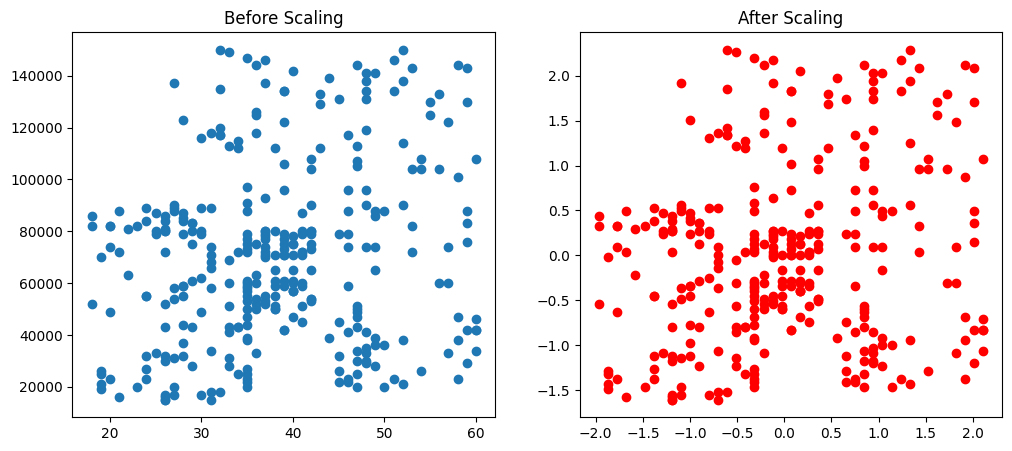

In [86]:
# we can see visul way , there is not differnt 
# Basic ploting appling and can see

fig, (ax1, ax2) = plt.subplots(ncols =2, figsize = (12, 5))

ax1.scatter(X_train['Age'], X_train ['EstimatedSalary'])
ax1.set_title('Before Scaling')

ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color ='red')
ax2.set_title('After Scaling')

plt.show()



In [ ]:
# meaning same but make small
# person name is jubyaer hussain to Jubayer

<Axes: title={'center': ' After scaling '}, xlabel='Age', ylabel='Density'>

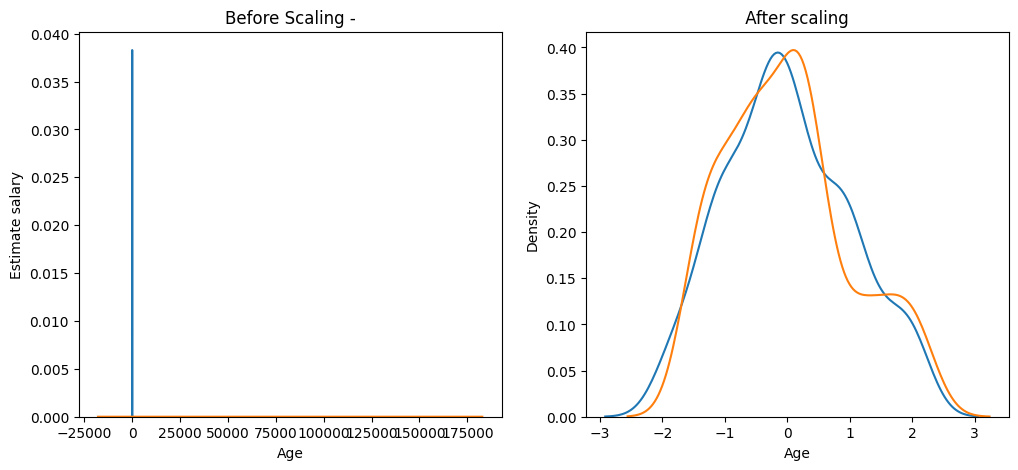

In [101]:
# kde plot(karnel density )

fig,(ax1, ax2) = plt.subplots(ncols =2, figsize = (12,5))
# before scaling 
ax1.set_title('Before Scaling -')
sns.kdeplot(X_train['Age'], ax =ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax =ax1)
ax1.set_xlabel('Age')
ax1.set_ylabel("Estimate salary")


# After Scaling 
ax2.set_title(' After scaling ')
sns.kdeplot(X_train_scaled['Age'],ax = ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax = ax2)